# High-frequency EMIC waves observed by Arase during the May 2024 Gannon storm

During the May 2024 geomagnetic superstorm, the Arase (ERG) spacecraft observed electromagnetic ion cyclotron (EMIC) waves deep in the inner magnetosphere. EMIC waves are low-frequency electromagnetic waves whose spectral bands are organized by ion gyrofrequencies. Because gyrofrequency increases with magnetic-field strength, waves observed close to Earth can occur at much higher frequencies than the more typical 0.2–5 Hz EMIC range.

In this notebook we will:

1. load Arase MGF, PWE/HFA, and orbit data with **PySPEDAS 2.2.0**;
2. inspect the 256 Hz magnetic waveform, its metadata, cadence, and gaps;
3. separate a slowly varying background field from fluctuations above 1 Hz;
4. construct a magnetic power spectral density (PSD) spectrogram;
5. calculate local H$^+$, He$^+$, and O$^+$ gyrofrequencies; and
6. compare the observed bands with density and location context.

The scientific motivation is [Jun et al. (2025), *Arase In Situ Observations of High-Frequency Electromagnetic Ion Cyclotron (EMIC) Waves in Regions Close to the Earth During the May 2024 Storm*](https://doi.org/10.1029/2024GL112489), especially their Figures 1, 3, and 4. We calculate our own introductory spectrum and **local** gyrofrequencies; we do not reproduce the paper's mean-field-aligned polarization analysis or model-mapped equatorial quantities.

> **Date note:** the Figure 3 caption in the paper says May 10–11, but the surrounding text, Figure 1, and the data identify this event as **May 11–12, 2024**. We use the latter dates.

## 1. Imports and time intervals

PySPEDAS 2.2.0 exposes the tplot functions through `pyspedas`. SciPy supplies a transparent filter and short-time Fourier transform. UTC-aware Python datetimes are used for the Matplotlib plots so that crossing midnight is unambiguous.

In [ ]:
# This line installs PySPEDAS so the notebook can be used in Google Colab.  You can comment
# it out or skip this cell if you already have a suitable PySPEDAS installation.

!pip install "pyspedas>=2.2.0"

In [1]:
%matplotlib inline

from datetime import datetime, timezone
from importlib.metadata import version
from pprint import pprint

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pyspedas
from scipy.constants import elementary_charge, proton_mass
from scipy.signal import butter, sosfiltfilt, spectrogram
from pyspedas import get_data, options, store_data, time_double, timebar, tplot

print("PySPEDAS version:", version("pyspedas"))

PySPEDAS version: 2.2.0


In [2]:
trange = ["2024-05-11/22:40", "2024-05-12/00:10"]
wave_trange = ["2024-05-11/23:55", "2024-05-12/00:06"]
paper_psd_trange = ["2024-05-11/23:56", "2024-05-11/23:57"]

first_event = ["2024-05-11/22:47", "2024-05-11/22:57"]
second_event = wave_trange
trange, wave_trange

(['2024-05-11/22:40', '2024-05-12/00:10'],
 ['2024-05-11/23:55', '2024-05-12/00:06'])

## 2. Load a low-cadence overview

We start with small context products rather than the waveform files:

- MGF Level 2, 8 s magnetic field;
- PWE/HFA Level 3, 1 min electron density inferred from the upper-hybrid resonance; and
- Level 2 orbit data.

The loaders return the names of the tplot variables they create. Loading both dates is necessary because the interval crosses midnight.

In [3]:
erg = pyspedas.projects.erg

mgf_overview_vars = erg.mgf(
    trange=trange, datatype="8sec", level="l2", time_clip=True
)
hfa_vars = erg.pwe_hfa(
    trange=trange, level="l3", time_clip=True
)
orbit_vars = erg.orb(
    trange=trange, level="l2", datatype="def", time_clip=True
)

print("MGF variables:", mgf_overview_vars)
print("HFA variables:", hfa_vars)
print("Orbit variables:", orbit_vars)

23-Sep-26 15:54:34: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/mgf/l2/8sec/2024/05/
23-Sep-26 15:54:36: Downloading https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/mgf/l2/8sec/2024/05/erg_mgf_l2_8sec_20240511_v04.06.cdf to erg_data/satellite/erg/mgf/l2/8sec/2024/05/erg_mgf_l2_8sec_20240511_v04.06.cdf
23-Sep-26 15:54:39: Download of erg_data/satellite/erg/mgf/l2/8sec/2024/05/erg_mgf_l2_8sec_20240511_v04.06.cdf complete, 1.549 MB in 2.9 sec (0.541 MB/sec) (transfer_slow)
23-Sep-26 15:54:40: Downloading https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/mgf/l2/8sec/2024/05/erg_mgf_l2_8sec_20240512_v04.06.cdf to erg_data/satellite/erg/mgf/l2/8sec/2024/05/erg_mgf_l2_8sec_20240512_v04.06.cdf
23-Sep-26 15:54:43: Download of erg_data/satellite/erg/mgf/l2/8sec/2024/05/erg_mgf_l2_8sec_20240512_v04.06.cdf complete, 1.549 MB in 3.1 sec (0.505 MB/sec) (transfer_slow)
23-Sep-26 15:54:43: Downloading remote index: https://ergsc.isee.nagoya-

 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Magnetic Field Experiment (MGF) Level 2 spin-averaged magnetic field data']

Information about ERG MGF

PI:  ['Ayako Matsuoka']
Affiliation:  ['Data Analysis Center for Geomagnetism and Space Magnetism, Graduate School of Science, Kyoto University, Kitashirakawa-Oiwake Cho, Sakyo-ku Kyoto 606-8502, Japan']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of MGF L2: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Mgf
Contact: erg_mgf_info at isee.nagoya-u.ac.jp
**************************************************************************


23-Sep-26 15:54:45: Downloading https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/pwe/hfa/l3/2024/05/erg_pwe_hfa_l3_1min_20240511_v06_11.cdf to erg_data/satellite/erg/pwe/hfa/l3/2024/05/erg_pwe_hfa_l3_1min_20240511_v06_11.cdf
23-Sep-26 15:54:45: Download of erg_data/satellite/erg/pwe/hfa/l3/2024/05/erg_pwe_hfa_l3_1min_20240511_v06_11.cdf complete, 0.025 MB in 0.3 sec (0.078 MB/sec) (transfer_normal)
23-Sep-26 15:54:47: Downloading https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/pwe/hfa/l3/2024/05/erg_pwe_hfa_l3_1min_20240512_v06_11.cdf to erg_data/satellite/erg/pwe/hfa/l3/2024/05/erg_pwe_hfa_l3_1min_20240512_v06_11.cdf
23-Sep-26 15:54:47: Download of erg_data/satellite/erg/pwe/hfa/l3/2024/05/erg_pwe_hfa_l3_1min_20240512_v06_11.cdf complete, 0.024 MB in 0.7 sec (0.035 MB/sec) (transfer_normal)
23-Sep-26 15:54:47: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/orb/def/2024/


 
 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Plasma Wave Experiment (PWE) High Frequency Analyzer (HFA) Level 3 UHR frequency and electron density data']

Information about ERG PWE HFA

PI:  ['Yoshiya Kasahara and Ayako Matsuoka']
Affiliation:  ['Kanazawa University and Kyoto University']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of PWE/HFA: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Pwe/Hfa

Contact: erg_pwe_info at isee.nagoya-u.ac.jp
**************************************************************************


23-Sep-26 15:54:50: Downloading https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/orb/def/2024/erg_orb_l2_20240511_v05.cdf to erg_data/satellite/erg/orb/def/2024/erg_orb_l2_20240511_v05.cdf
23-Sep-26 15:54:52: Download of erg_data/satellite/erg/orb/def/2024/erg_orb_l2_20240511_v05.cdf complete, 2.116 MB in 2.8 sec (0.758 MB/sec) (transfer_slow)
23-Sep-26 15:54:54: Downloading https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/orb/def/2024/erg_orb_l2_20240512_v05.cdf to erg_data/satellite/erg/orb/def/2024/erg_orb_l2_20240512_v05.cdf
23-Sep-26 15:54:56: Download of erg_data/satellite/erg/orb/def/2024/erg_orb_l2_20240512_v05.cdf complete, 2.107 MB in 2.7 sec (0.790 MB/sec) (transfer_slow)


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Level-2 orbit data']

Information about ERG orbit


RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en

Contact: erg-sc-core at isee.nagoya-u.ac.jp
**************************************************************************
MGF variables: ['erg_mgf_l2_epoch_8sec', 'erg_mgf_l2_mag_8sec_dsi', 'erg_mgf_l2_mag_8sec_gse', 'erg_mgf_l2_mag_8sec_gsm', 'erg_mgf_l2_mag_8sec_sm', 'erg_mgf_l2_magt_8sec', 'erg_mgf_l2_rmsd_8sec_dsi', 'erg_mgf_l2_rmsd_8sec_gse', 'erg_mgf_l2_rmsd_8sec_gsm', 'erg_mgf_l2_rmsd_8sec_sm', 'erg_mgf_l2_rmsd_8sec', 'erg_mgf_l2_n_rmsd_8sec', 'erg_mgf_l2_dyn_rng_8sec', 'erg_mgf_l2_quality_8sec', 'erg_mgf_l2_quality_8sec_gc', 'erg_mgf_l2_igrf_8sec_dsi', 'erg_mgf_l2_igrf_8sec_gse', 'erg_mgf_l2_igrf_8sec_gsm', 'erg_mgf_l2_igrf_8sec_sm']
HFA variables: ['erg_pwe_hfa_l3_1min_Epoch', 'erg_pwe_hfa_l3_1m

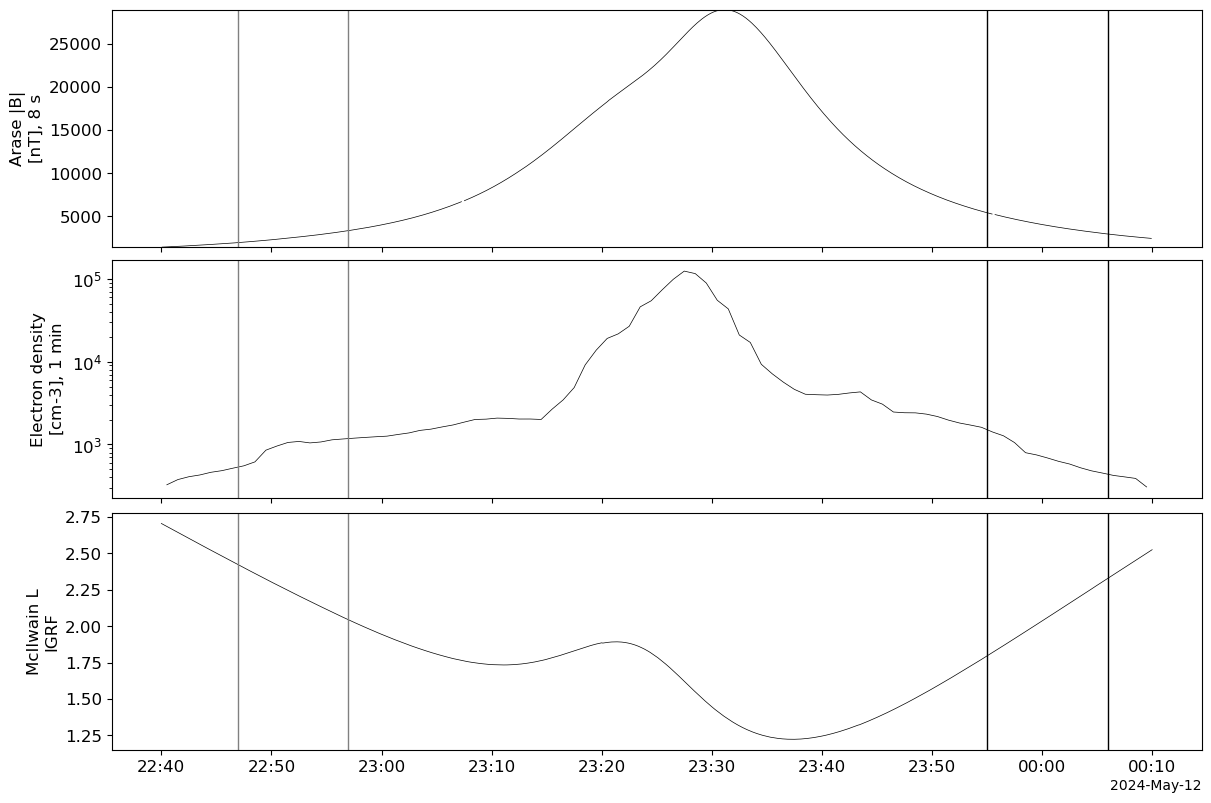

In [4]:
bmag_overview = "erg_mgf_l2_magt_8sec"
density_var = "erg_pwe_hfa_l3_1min_ne_mgf"
orbit_l_var = "erg_orb_l2_pos_Lm"
orbit_position_var = "erg_orb_l2_pos_rmlatmlt"

expected_context = [bmag_overview, density_var, orbit_l_var, orbit_position_var]
returned_context = mgf_overview_vars + hfa_vars + orbit_vars
for name in expected_context:
    if name not in returned_context or get_data(name) is None:
        raise RuntimeError(f"Expected context variable {name!r} was not loaded")

# The three delivered McIlwain-L estimates differ only by pitch angle. Their
# median gives one uncluttered context trace without relying on component order.
l_data = get_data(orbit_l_var)
store_data(
    "erg_orb_L_median",
    data={"x": l_data.times, "y": np.nanmedian(l_data.y, axis=1)},
)

options(bmag_overview, "ytitle", "Arase |B|")
options(bmag_overview, "ysubtitle", "[nT], 8 s")
options(density_var, "ytitle", "Electron density")
options(density_var, "ysubtitle", "[cm^-3], 1 min")
options(density_var, "ylog", True)
options("erg_orb_L_median", "ytitle", "McIlwain L")
options("erg_orb_L_median", "ysubtitle", "IGRF")

for event_time, color in [
    (first_event[0], "gray"), (first_event[1], "gray"),
    (second_event[0], "red"), (second_event[1], "red"),
]:
    timebar(time_double(event_time), color=color, thick=1)

tplot([bmag_overview, density_var, "erg_orb_L_median"], xsize=12, ysize=8)

The gray guides mark the first reported HF EMIC interval (22:47–22:57 UT); the red guides mark the multiband event used below (23:55–00:06 UT). Before proceeding, notice the several-thousand-nT field, high density, and low L shell. These are very different conditions from a typical outer-magnetosphere EMIC event.

### Inspect context metadata

The HFA product name is not obvious from the loader call: in PySPEDAS 2.2.0 the density is `erg_pwe_hfa_l3_1min_ne_mgf`. The metadata confirm that its units are particles per cubic centimeter (`/cc`).

In [5]:
for name in [bmag_overview, density_var, orbit_l_var, orbit_position_var]:
    metadata = get_data(name, metadata=True)
    data = get_data(name)
    cadence = np.nanmedian(np.diff(data.times))
    print(f"\n{name}: {len(data.times)} samples, median cadence {cadence:.3f} s")
    pprint({
        "units": metadata.get("data_att", {}).get("units"),
        "coordinate_system": metadata.get("data_att", {}).get("coord_sys"),
        "field_name": metadata.get("CDF", {}).get("VATT", {}).get("FIELDNAM"),
        "description": metadata.get("CDF", {}).get("VATT", {}).get("CATDESC"),
    })


erg_mgf_l2_magt_8sec: 669 samples, median cadence 8.042 s
{'coordinate_system': '',
 'description': '8 sec resolution total B',
 'field_name': 'Bt',
 'units': 'nT'}

erg_pwe_hfa_l3_1min_ne_mgf: 90 samples, median cadence 59.999 s
{'coordinate_system': '',
 'description': 'density_mgf',
 'field_name': 'density_mgf',
 'units': '/cc'}

erg_orb_l2_pos_Lm: 901 samples, median cadence 6.000 s
{'coordinate_system': '',
 'description': "McIlwain's L parameter for pitch angles of 30, 60, and 90 "
                'deg, in descending order',
 'field_name': "McIlwain's L parameter",
 'units': 'dimensionless'}

erg_orb_l2_pos_rmlatmlt: 901 samples, median cadence 6.000 s
{'coordinate_system': '',
 'description': 'R, magnetic latitude, and magnetic local time of spacecraft '
                'positions (using IGRF model)',
 'field_name': 'Positions R MLAT MLT',
 'units': 'RE deg hour'}


## 3. Load and inspect the 256 Hz waveform

The 256 Hz MGF data are a special high-rate mode available at low L shell. Unlike the 8 s context product, these data resolve fluctuations up to a Nyquist frequency near 128 Hz. The loader uses hourly files, so this 11-minute interval downloads the 23 UT and 00 UT files on a first run; later runs use the cache.

In [6]:
wave_vars = erg.mgf(
    trange=wave_trange,
    datatype="256hz",
    level="l2",
    coord="dsi",
    time_clip=True,
)
print("256 Hz MGF variables:", wave_vars)

wave_var = "erg_mgf_l2_mag_256hz_dsi"
if wave_var not in wave_vars or get_data(wave_var) is None:
    raise RuntimeError(f"Expected waveform variable {wave_var!r} was not loaded")

23-Sep-26 15:54:56: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/mgf/l2/256hz/2024/05/
23-Sep-26 15:55:02: Downloading https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/mgf/l2/256hz/2024/05/erg_mgf_l2_256hz_dsi_2024051123_v04.06.cdf to erg_data/satellite/erg/mgf/l2/256hz/2024/05/erg_mgf_l2_256hz_dsi_2024051123_v04.06.cdf
23-Sep-26 15:55:15: Download of erg_data/satellite/erg/mgf/l2/256hz/2024/05/erg_mgf_l2_256hz_dsi_2024051123_v04.06.cdf complete, 15.574 MB in 13.9 sec (1.124 MB/sec) (transfer_normal)
23-Sep-26 15:55:17: Downloading https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/mgf/l2/256hz/2024/05/erg_mgf_l2_256hz_dsi_2024051200_v04.06.cdf to erg_data/satellite/erg/mgf/l2/256hz/2024/05/erg_mgf_l2_256hz_dsi_2024051200_v04.06.cdf
23-Sep-26 15:55:25: Download of erg_data/satellite/erg/mgf/l2/256hz/2024/05/erg_mgf_l2_256hz_dsi_2024051200_v04.06.cdf complete, 11.559 MB in 8.9 sec (1.298 MB/sec) (transfer_normal)
23-Sep-26 15:55:

 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Magnetic Field Experiment (MGF) Level 2 256 Hz resolution magnetic field data']

Information about ERG MGF

PI:  ['Ayako Matsuoka']
Affiliation:  ['Data Analysis Center for Geomagnetism and Space Magnetism, Graduate School of Science, Kyoto University, Kitashirakawa-Oiwake Cho, Sakyo-ku Kyoto 606-8502, Japan']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of MGF L2: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Mgf
Contact: erg_mgf_info at isee.nagoya-u.ac.jp
**************************************************************************
256 Hz MGF variables: ['erg_mgf_l2_epoch_256hz', 'erg_mgf_l2_date_time_256hz', 'erg_mgf_l2_mag_256hz_dsi', 'erg_mgf_l2_dyn_rng_256hz', 'erg_mgf_l2_quality_256hz', 'erg_mgf_l2_quality_256hz_gc', 'erg_mgf_l2_spin_phase_256hz', 'erg_mgf_l2_ti_256hz']


In [7]:
wave_data = get_data(wave_var)
wave_metadata = get_data(wave_var, metadata=True)
wave_times = np.asarray(wave_data.times)
wave_b = np.asarray(wave_data.y, dtype=float)

dt = np.diff(wave_times)
# Exclude obvious gaps when estimating the delivered cadence.
short_dt = dt[dt < 0.02]
sample_dt = np.nanmedian(short_dt)
sample_rate = 1.0 / sample_dt
nyquist = sample_rate / 2.0
finite_rows = np.all(np.isfinite(wave_b), axis=1)
gap_threshold = 5.0 * sample_dt
gap_indices = np.flatnonzero(dt > gap_threshold)

print(f"Waveform shape: {wave_b.shape}")
print(f"Measured median cadence: {sample_dt * 1000:.4f} ms")
print(f"Effective sample rate: {sample_rate:.3f} Hz")
print(f"Nyquist frequency: {nyquist:.3f} Hz")
print(f"Rows with three finite components: {finite_rows.mean():.3%}")
print(f"Time gaps larger than {gap_threshold:.4f} s: {len(gap_indices)}")
for i in gap_indices:
    t0 = datetime.fromtimestamp(wave_times[i], tz=timezone.utc)
    t1 = datetime.fromtimestamp(wave_times[i + 1], tz=timezone.utc)
    print(f"  {t0.isoformat()} to {t1.isoformat()} ({dt[i]:.3f} s)")

pprint({
    "units": wave_metadata.get("data_att", {}).get("units"),
    "coordinate_system_attribute": wave_metadata.get("data_att", {}).get("coord_sys"),
    "labels": wave_metadata.get("CDF", {}).get("LABELS"),
    "field_name": wave_metadata.get("CDF", {}).get("VATT", {}).get("FIELDNAM"),
    "description": wave_metadata.get("CDF", {}).get("VATT", {}).get("CATDESC"),
})

Waveform shape: (167571, 3)
Measured median cadence: 3.9001 ms
Effective sample rate: 256.407 Hz
Nyquist frequency: 128.203 Hz
Rows with three finite components: 98.772%
Time gaps larger than 0.0195 s: 1
  2024-05-11T23:59:52.893152+00:00 to 2024-05-11T23:59:58.704677+00:00 (5.812 s)
{'coordinate_system_attribute': '',
 'description': 'B in DSI coordinates',
 'field_name': 'B in DSI',
 'labels': ['Bx', 'By', 'Bz'],
 'units': 'nT'}


The variable name and CDF description identify **DSI coordinates**, and the units are nT. In the current files the generic `coord_sys` metadata field is blank, which is why checking more than one metadata key matters.

The cadence is close to, but not exactly, the nominal 256 Hz when estimated from time tags. We use the measured median cadence for the frequency axis. We also keep gaps as gaps: filtering across missing data would create false ringing, and concatenating separated samples before an FFT would create spurious spectral power.

## 4. Separate the background field and wave fluctuations

We estimate the slowly varying background field $\mathbf{B}_0$ with a fourth-order Butterworth low-pass filter at 1 Hz and define

$$\delta\mathbf{B} = \mathbf{B} - \mathbf{B}_0.$$

The filter is applied forward and backward (`sosfiltfilt`), so it introduces no phase shift. Every continuous, finite segment is filtered separately. A 1 Hz cutoff is well below the 5–35 Hz emissions emphasized by Jun et al., while retaining the field variation needed for gyrofrequencies.

In [8]:
# Split at timing gaps and at every transition into or out of invalid data.
breaks = np.flatnonzero(
    (dt > gap_threshold) | (~finite_rows[:-1]) | (~finite_rows[1:])
) + 1
candidate_segments = np.split(np.arange(len(wave_times)), breaks)

# A 16 s spectrum needs about 4096 samples. Short fragments are not useful here.
nperseg = 4096
segments = [
    index for index in candidate_segments
    if len(index) >= nperseg and finite_rows[index].all()
]

lowpass_sos = butter(4, 1.0, btype="lowpass", fs=sample_rate, output="sos")
background_b = np.full_like(wave_b, np.nan)
wave_fluctuations = np.full_like(wave_b, np.nan)

for index in segments:
    background_b[index] = sosfiltfilt(lowpass_sos, wave_b[index], axis=0)
    wave_fluctuations[index] = wave_b[index] - background_b[index]

print("Continuous segments used:")
for index in segments:
    start = datetime.fromtimestamp(wave_times[index[0]], tz=timezone.utc)
    stop = datetime.fromtimestamp(wave_times[index[-1]], tz=timezone.utc)
    print(f"  {start.isoformat()} to {stop.isoformat()}: {len(index):,} samples")

Continuous segments used:
  2024-05-11T23:55:00.003034+00:00 to 2024-05-11T23:55:35.763158+00:00: 9,161 samples
  2024-05-11T23:55:43.800808+00:00 to 2024-05-11T23:59:52.893152+00:00: 63,806 samples
  2024-05-11T23:59:58.704677+00:00 to 2024-05-12T00:05:59.997893+00:00: 92,546 samples


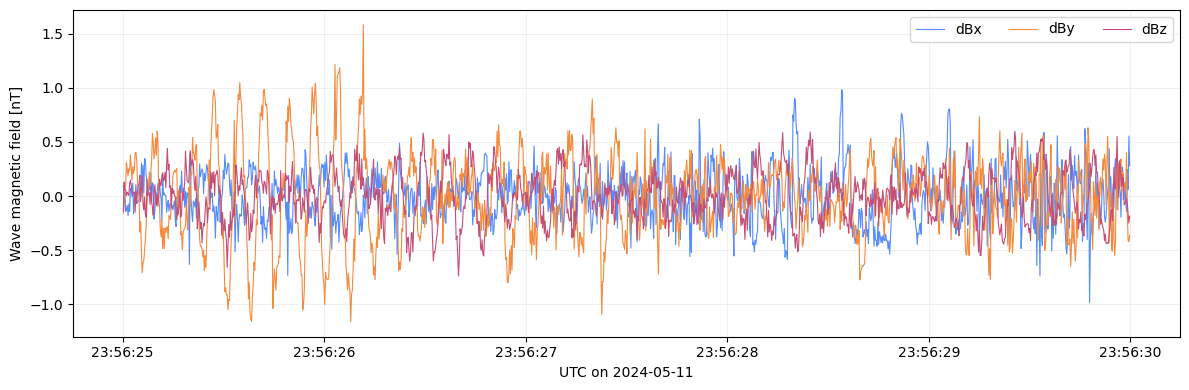

In [9]:
# A five-second waveform zoom makes the high-rate character tangible.
zoom = time_double(["2024-05-11/23:56:25", "2024-05-11/23:56:30"])
zoom_mask = (
    (wave_times >= zoom[0]) & (wave_times <= zoom[1])
    & np.all(np.isfinite(wave_fluctuations), axis=1)
)
zoom_times = [datetime.fromtimestamp(t, tz=timezone.utc) for t in wave_times[zoom_mask]]

fig, ax = plt.subplots(figsize=(12, 4))
for component, label in enumerate(["dBx", "dBy", "dBz"]):
    ax.plot(zoom_times, wave_fluctuations[zoom_mask, component], lw=0.8, label=label)
ax.set_ylabel("Wave magnetic field [nT]")
ax.set_xlabel("UTC on 2024-05-11")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S", tz=timezone.utc))
ax.legend(ncol=3)
ax.grid(alpha=0.25)
fig.tight_layout()

## 5. Construct the magnetic PSD spectrogram

PySPEDAS 2.2.0 includes `tdpwrspc`, which is convenient for a continuous scalar tplot variable. Here we use SciPy's `spectrogram` directly because we want to (1) preserve multiple gaps, (2) sum the three component PSDs into a coordinate-invariant total magnetic PSD, and (3) expose every window choice to students.

Following the cadence reported by Jun et al., we use a **16 s Hann window stepped by 5 s**. With approximately 256 samples/s, 4096 points give about 0.063 Hz frequency resolution. PSD has units of nT$^2$/Hz. The 1 Hz high-pass separation has already removed the large background trend.

In [10]:
step_seconds = 5.0
step_samples = int(round(step_seconds * sample_rate))
noverlap = nperseg - step_samples
spectra = []

for index in segments:
    if len(index) < nperseg:
        continue
    total_psd = None
    for component in range(3):
        frequencies, relative_times, component_psd = spectrogram(
            wave_fluctuations[index, component],
            fs=sample_rate,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            detrend=False,
            scaling="density",
            mode="psd",
        )
        total_psd = component_psd if total_psd is None else total_psd + component_psd
    spectra.append({
        "times": wave_times[index[0]] + relative_times,
        "frequencies": frequencies,
        "psd": total_psd,
    })

print(f"Window length: {nperseg / sample_rate:.2f} s")
print(f"Window step: {step_samples / sample_rate:.2f} s")
print(f"Frequency resolution: {frequencies[1] - frequencies[0]:.4f} Hz")
print(f"Number of spectra: {sum(item['psd'].shape[1] for item in spectra)}")

Window length: 15.97 s
Window step: 5.00 s
Frequency resolution: 0.0626 Hz
Number of spectra: 120


## 6. Calculate ion gyrofrequencies

For an ion with charge magnitude $|q_i|$ and mass $m_i$,

$$f_{ci}=\frac{|q_i|B}{2\pi m_i}.$$

MGF reports nT, so we multiply by $10^{-9}$ before using the SI formula. For singly ionized H$^+$, He$^+$, and O$^+$ the charge is the same; using mass numbers 1, 4, and 16 gives $f_{cHe}\approx f_{cH}/4$ and $f_{cO}\approx f_{cH}/16$.

These are **local** gyrofrequencies from the measured, low-pass-filtered field magnitude. The paper also uses model-mapped equatorial field quantities for parts of its analysis; those are not interchangeable with the local values calculated here.

In [11]:
background_bmag = np.linalg.norm(background_b, axis=1)
valid_background = np.isfinite(background_bmag)

def gyrofrequency_hz(b_nT, mass_number):
    b_tesla = np.asarray(b_nT) * 1e-9
    return elementary_charge * b_tesla / (2.0 * np.pi * mass_number * proton_mass)

f_cH = gyrofrequency_hz(background_bmag, 1)
f_cHe = gyrofrequency_hz(background_bmag, 4)
f_cO = gyrofrequency_hz(background_bmag, 16)

print("Local gyrofrequency ranges over finite waveform samples:")
for label, values in [("H+", f_cH), ("He+", f_cHe), ("O+", f_cO)]:
    print(f"  {label:3s}: {np.nanmin(values):6.2f} to {np.nanmax(values):6.2f} Hz")

Local gyrofrequency ranges over finite waveform samples:
  H+ :  45.14 to  83.18 Hz
  He+:  11.28 to  20.80 Hz
  O+ :   2.82 to   5.20 Hz


## 7. Overlay the gyrofrequencies on the spectrum

The frequency axis is logarithmic so all three gyrofrequency tracks fit without hiding the 5–35 Hz structure. In a multi-ion plasma the conventional bands are:

- H$^+$ band: $f_{cHe}<f<f_{cH}$;
- He$^+$ band: $f_{cO}<f<f_{cHe}$; and
- O$^+$ band: $f<f_{cO}$.

These boundaries organize the observations, but a band location alone is not a complete wave-mode or polarization diagnosis.

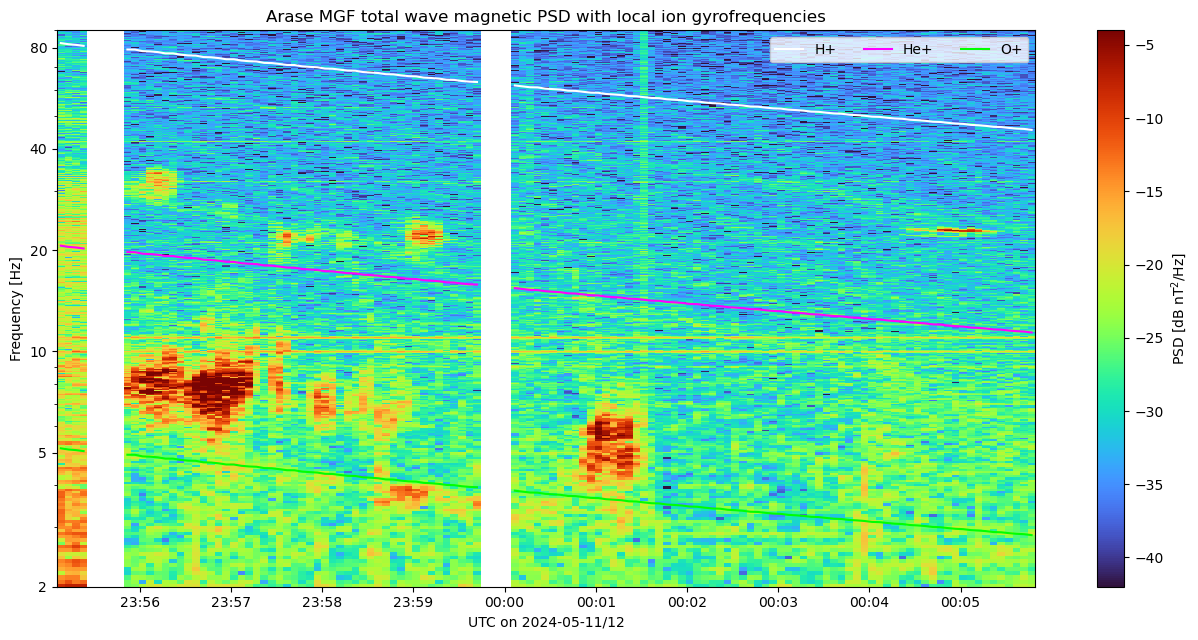

In [12]:
fig, ax = plt.subplots(figsize=(13, 6.5))
mesh = None
colors = {"H+": "white", "He+": "magenta", "O+": "lime"}

for segment_number, item in enumerate(spectra):
    plot_frequency = item["frequencies"]
    frequency_mask = (plot_frequency >= 2.0) & (plot_frequency <= 90.0)
    plot_times = [datetime.fromtimestamp(t, tz=timezone.utc) for t in item["times"]]
    psd_db = 10.0 * np.log10(item["psd"][frequency_mask])
    mesh = ax.pcolormesh(
        plot_times,
        plot_frequency[frequency_mask],
        psd_db,
        shading="auto",
        cmap="turbo",
        vmin=-42,
        vmax=-4,
    )

    b_for_spectrum = np.interp(
        item["times"], wave_times[valid_background], background_bmag[valid_background]
    )
    tracks = {
        "H+": gyrofrequency_hz(b_for_spectrum, 1),
        "He+": gyrofrequency_hz(b_for_spectrum, 4),
        "O+": gyrofrequency_hz(b_for_spectrum, 16),
    }
    for label, track in tracks.items():
        ax.plot(
            plot_times, track, color=colors[label], lw=1.5,
            label=label if segment_number == 0 else None,
        )

ax.set_yscale("log")
ax.set_ylim(2, 90)
ax.set_yticks([2, 5, 10, 20, 40, 80])
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_ylabel("Frequency [Hz]")
ax.set_xlabel("UTC on 2024-05-11/12")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=timezone.utc))
ax.set_title("Arase MGF total wave magnetic PSD with local ion gyrofrequencies")
ax.legend(loc="upper right", ncol=3)
fig.colorbar(mesh, ax=ax, label=r"PSD [dB nT$^2$/Hz]")
fig.tight_layout()

The strongest packets near 5–10 Hz lie between the local O$^+$ and He$^+$ gyrofrequencies and are therefore naturally described as He$^+$-band emissions. Weaker isolated power near 20–35 Hz lies above $f_{cHe}$ and below $f_{cH}$, in the H$^+$ band. This is the unusual high-frequency part of the event emphasized by Jun et al.

The broad vertical changes at data-segment edges are not interpreted as waves. They illustrate why the gap check and segment-by-segment processing are essential.

### One-minute average spectrum: 23:56–23:57 UT

Jun et al. use this minute for their Figure 4 PSD and resonance calculation. We only average our total magnetic PSD and mark the mean **local** gyrofrequencies. The published paper reports well-defined He$^+$-band power at 5–10 Hz and H$^+$-band power at 27–35 Hz.

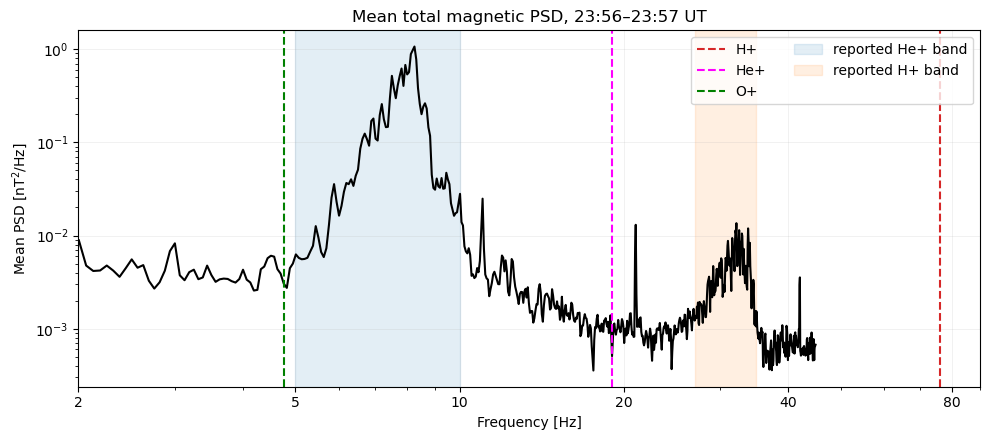

In [13]:
psd_start, psd_stop = time_double(paper_psd_trange)
selected_columns = []
selected_times = []
for item in spectra:
    inside = (item["times"] >= psd_start) & (item["times"] < psd_stop)
    if np.any(inside):
        selected_columns.append(item["psd"][:, inside])
        selected_times.append(item["times"][inside])

minute_psd = np.nanmean(np.concatenate(selected_columns, axis=1), axis=1)
minute_times = np.concatenate(selected_times)
minute_b = np.nanmean(np.interp(
    minute_times, wave_times[valid_background], background_bmag[valid_background]
))

fig, ax = plt.subplots(figsize=(10, 4.5))
frequency_mask = (frequencies >= 2) & (frequencies <= 45)
ax.semilogy(frequencies[frequency_mask], minute_psd[frequency_mask], color="black")
average_colors = {"H+": "red", "He+": "magenta", "O+": "green"}
for label, mass_number in [("H+", 1), ("He+", 4), ("O+", 16)]:
    ax.axvline(
        gyrofrequency_hz(minute_b, mass_number),
        color=average_colors[label], lw=1.5, ls="--", label=label,
    )
ax.axvspan(5, 10, color="blue", alpha=0.12, label="reported He+ band")
ax.axvspan(27, 35, color="orange", alpha=0.12, label="reported H+ band")
ax.set_xscale("log")
ax.set_xlim(2, 90)
ax.set_xticks([2, 5, 10, 20, 40, 80])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel(r"Mean PSD [nT$^2$/Hz]")
ax.set_title("Mean total magnetic PSD, 23:56–23:57 UT")
ax.grid(alpha=0.25)
ax.legend(ncol=2)
fig.tight_layout()

## 8. Density and spacecraft-location context

The HFA density is inferred from the upper-hybrid resonance rather than measured by a particle counter. The orbit product supplies geocentric radius, IGRF magnetic latitude (MLAT), magnetic local time (MLT), and McIlwain L. We show the median of the three pitch-angle-dependent L estimates.

Focused-interval median density [cm^-3]: 687.25824
Focused-interval density range [cm^-3]: 451.63312 1416.543
Focused-interval median [R, MLAT, MLT]: [ 2.0667727 11.364063   8.07391  ]
Focused-interval median McIlwain L: 2.0603752


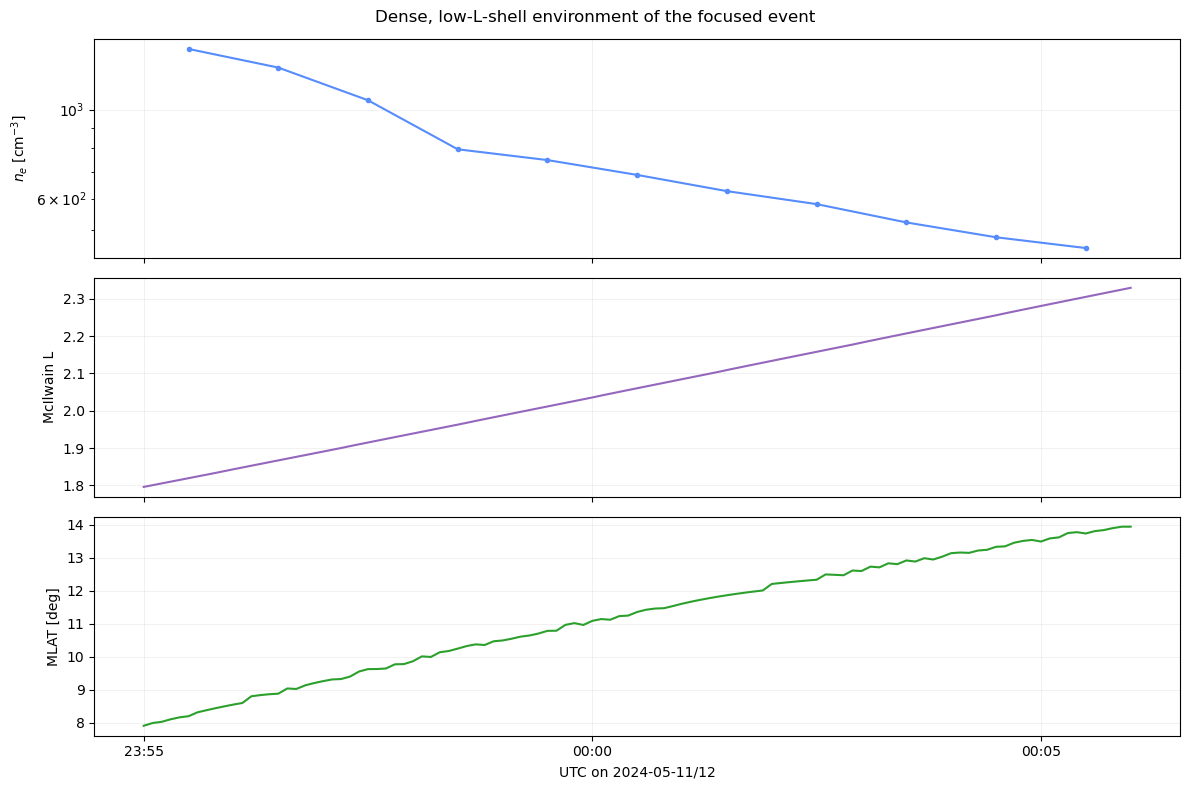

In [14]:
density = get_data(density_var)
position = get_data(orbit_position_var)
orbit_l = get_data(orbit_l_var)
context_start, context_stop = time_double(wave_trange)

density_mask = (density.times >= context_start) & (density.times <= context_stop)
position_mask = (position.times >= context_start) & (position.times <= context_stop)
l_mask = (orbit_l.times >= context_start) & (orbit_l.times <= context_stop)

context_times_density = [
    datetime.fromtimestamp(t, tz=timezone.utc) for t in density.times[density_mask]
]
context_times_orbit = [
    datetime.fromtimestamp(t, tz=timezone.utc) for t in position.times[position_mask]
]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].semilogy(context_times_density, density.y[density_mask], marker="o", ms=3)
axes[0].set_ylabel(r"$n_e$ [cm$^{-3}$]")

axes[1].plot(
    context_times_orbit,
    np.nanmedian(orbit_l.y[l_mask], axis=1),
    color="purple",
)
axes[1].set_ylabel("McIlwain L")

axes[2].plot(context_times_orbit, position.y[position_mask, 1], color="green")
axes[2].set_ylabel("MLAT [deg]")
axes[2].set_xlabel("UTC on 2024-05-11/12")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=timezone.utc))

for ax in axes:
    ax.grid(alpha=0.25)
fig.suptitle("Dense, low-L-shell environment of the focused event")
fig.tight_layout()

print("Focused-interval median density [cm^-3]:", np.nanmedian(density.y[density_mask]))
print("Focused-interval density range [cm^-3]:",
      np.nanmin(density.y[density_mask]), np.nanmax(density.y[density_mask]))
print("Focused-interval median [R, MLAT, MLT]:",
      np.nanmedian(position.y[position_mask], axis=0))
print("Focused-interval median McIlwain L:",
      np.nanmedian(orbit_l.y[l_mask]))

The event occurs near L $\sim$ 2 with density of hundreds to more than one thousand cm$^{-3}$. The large local magnetic field at low L shell raises the ion gyrofrequencies, while the dense cold plasma is relevant to EMIC-wave generation and propagation. Establishing that context does not require a full dispersion-relation calculation.

The paper reports a wave-normal angle analysis and polarization properties in a mean-field-aligned coordinate system. Our summed three-component PSD is rotation invariant and is sufficient to identify the bands, but it intentionally does not classify polarization.

## 9. Exercises

1. Hide or comment out the gyrofrequency curves in the central figure. At what frequencies and times do you identify the strongest isolated bands?
2. Choose one time near 23:56:30 UT. Read $|B_0|$ from `background_bmag` and calculate $f_{cH}$ by hand. Compare with `gyrofrequency_hz`.
3. Which observed packets fall naturally in the H$^+$ band and which in the He$^+$ band? Does the O$^+$ gyrofrequency pass through the strongest emission?
4. Change `nperseg` from 4096 to 2048 while keeping a similar fractional overlap. How do the time and frequency resolutions change? Which structures become easier or harder to see?
5. Compare the first interval (22:47–22:57 UT) with the second. Because that requires another hourly 256 Hz file, do it as an extension rather than adding it to the default download.
6. Change the background cutoff from 1 Hz to 0.5 or 2 Hz. Which parts of the 5–35 Hz spectrum are stable, and where do filter-edge effects appear?
7. Do the observed bands track the changing gyrofrequency curves, or are individual packets more nearly horizontal over their short lifetimes?

**Advanced extension:** `pyspedas.twavpol` provides polarization power, degree of polarization, ellipticity/helicity, and wave-normal products for a three-component tplot variable. Before interpreting those outputs, rotate into a mean-field-aligned system and test the routine on each continuous segment separately. That analysis is beyond this introductory notebook.

## 10. Scientific takeaway

Arase observed isolated magnetic-wave packets at unusually high frequencies during the May 2024 superstorm. The 256 Hz MGF waveform resolves strong 5–10 Hz power and weaker 20–35 Hz power while the spacecraft was in a dense plasma environment near L $\sim$ 2. Calculating gyrofrequencies directly from the measured background field organizes those emissions into He$^+$ and H$^+$ bands.

What we calculated here: a gap-aware, three-component magnetic PSD; a 1 Hz low-pass background field; local H$^+$, He$^+$, and O$^+$ gyrofrequencies; and simple density/orbit context.

What comes from Jun et al. (2025): the event selection, the interpretation as high-frequency EMIC waves, the detailed mean-field-aligned polarization and wave-normal analysis, and the reported 5–10 Hz and 27–35 Hz bands for 23:56–23:57 UT.

## Instructor notes and current caveats

- A fresh focused run downloads two hourly MGF 256 Hz files because the interval crosses midnight. In the archive version tested while developing this notebook, they were about **15.6 MB** and **11.6 MB**. The overview MGF, HFA, and orbit files add only a few MB.
- The ERG server returned all required files, but directory-index responses occasionally took tens of seconds. Reruns use the local cache.
- The current archive supplied MGF v04.06, HFA L3 v06.11, and orbit L2 v05. Jun et al. list earlier versions in their data-availability statement; small numerical or visual differences from the paper are therefore expected.
- In PySPEDAS 2.2.0, the MGF loader's `varnames` argument does not reduce the returned MGF variables. The notebook therefore validates the expected variable after loading rather than assuming a filtered return list.
- The high-rate variable is `erg_mgf_l2_mag_256hz_dsi`. Its name and CDF description identify DSI coordinates, but the generic `coord_sys` metadata entry is blank in the files tested.
- The measured median cadence is slightly different from exactly 1/256 s, so the notebook derives the frequency axis from the time tags. There are short gaps and invalid samples; filtering and spectral calculations are performed separately on continuous finite segments.
- The 16 s window and 5 s step follow the analysis cadence stated by Jun et al. The fixed color limits were chosen for the current archive version and should be rechecked if calibration versions change.
- HFA L3 density has 1 min cadence and includes a quality flag. This introductory plot shows the delivered density without interpreting the flag bit mask; research use should consult the product documentation.
- The central spectrum sums DSI-component PSDs and is invariant under rotation. It is not the paper's perpendicular/parallel mean-field-aligned spectrum and cannot by itself determine polarization or wave-normal angle.
- ERG/Arase rules of use and instrument-team citation guidance printed by the loaders should be followed for presentations and publications.